1. Import Relevant Modules

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


2. Perform Exploratory Data Analysis

In [54]:
df = pd.read_csv('/Users/laven/Documents/TKH/shopping-behavior/data/raw/shopping.csv')
cdf = df.dropna()

cdf.info()
cdf.head()
cdf.describe()


<class 'pandas.DataFrame'>
Index: 479 entries, 8 to 1878
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             479 non-null    int64  
 1   Age                     479 non-null    float64
 2   Gender                  479 non-null    str    
 3   Item Purchased          479 non-null    str    
 4   Purchase Amount (USD)   479 non-null    float64
 5   Location                479 non-null    str    
 6   Size                    479 non-null    str    
 7   Color                   479 non-null    str    
 8   Season                  479 non-null    str    
 9   Review Rating           479 non-null    float64
 10  Shipping Type           479 non-null    str    
 11  Promo Code Used         479 non-null    str    
 12  Previous Purchases      479 non-null    int64  
 13  Payment Method          479 non-null    str    
 14  Frequency of Purchases  479 non-null    str    
dtypes: f

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,479.000000,479.000000,479.000000,479.000000,479.000000
mean,2792.895616,34.365344,30.424959,3.937370,7.924843
std,642.838744,10.428785,5.827466,1.066925,6.142195
min,1678.000000,18.000000,13.853021,1.000000,1.000000
25%,2251.500000,26.500000,26.464710,4.000000,3.000000
50%,2812.000000,33.000000,30.329423,4.000000,6.000000
75%,3331.500000,41.000000,34.634069,5.000000,12.000000
max,3897.000000,73.000000,47.750082,5.000000,20.000000


1. Which age group makes the most purchases?

In [4]:
previous_purchases_by_age = cdf[['Age', "Previous Purchases"]].sort_values(by = ["Previous Purchases"], ascending= False).head(10)
print(previous_purchases_by_age)



       Age  Previous Purchases
1017  23.0                  20
1140  30.0                  20
1755  34.0                  20
1625  33.0                  20
341   47.0                  20
1127  28.0                  20
526   38.0                  20
524   20.0                  20
518   58.0                  20
1253  27.0                  20


2. Which Gender makes the most purchases? find max of previous purchases by gender.

In [ ]:
previous_purchases_by_gender = cdf[['Gender', "Previous Purchases"]].groupby(by = ["Gender"]).sum()
print(previous_purchases_by_gender)



            Previous Purchases
Gender                        
Female                    1815
Male                      1901
Non-binary                  80


The maximum number of previous purchases is made by males, a total of 1901 purchases, 86 more previous purchases than females.

3. Which item is the most popular in the shopping catalogue? do a count of item purchased column.

In [21]:
popular_item = cdf[['Item Purchased', "Previous Purchases"]].groupby(by = ["Item Purchased"]).count()
print(popular_item.sort_values(by="Previous Purchases", ascending= False))


                Previous Purchases
Item Purchased                    
Sunglasses                      43
Running Shoes                   41
Dress                           38
Sweater                         35
Handbag                         35
T-shirt                         31
Shorts                          31
Socks                           29
Hoodie                          28
Boots                           26
Scarf                           26
Leggings                        24
Gloves                          24
Jacket                          22
Pajamas                         20
Backpack                        19
Belt                             5
Jeans                            2


Sunglasses, Running shoes, and Dresses were among the most popular items purchased in the dataset.

 4. what is the purchase amount of the most popular item purchased in the shopping catalog?

In [45]:
popular_item_price = cdf[["Item Purchased", "Purchase Amount (USD)"]].groupby(by="Item Purchased").mean()
print(popular_item_price.sort_values(by = "Purchase Amount (USD)", ascending= False))


                Purchase Amount (USD)
Item Purchased                       
Belt                        32.555693
Dress                       32.063498
Leggings                    31.485048
Pajamas                     31.034518
T-shirt                     30.931841
Running Shoes               30.752726
Gloves                      30.432443
Socks                       30.417681
Jacket                      30.359787
Sunglasses                  30.318268
Handbag                     30.257926
Scarf                       30.090402
Backpack                    30.069009
Sweater                     30.052853
Hoodie                      29.835899
Shorts                      29.488976
Jeans                       29.462447
Boots                       28.429400


## Required Analytical Questions
1. What are the most popular colors by season?

In [102]:
popular_color = pd.pivot_table(cdf, values='Previous Purchases', index=["Color"],
                       columns=['Season'], aggfunc="sum").sort_values(by = ["Fall"],ascending= False)
print(popular_color)


Season                 Fall  Spring  Summer  Winter
Color                                              
Black                 156.0     NaN     1.0   224.0
Brown                 151.0     NaN    27.0    79.0
Ruby Red              118.0     NaN     NaN   113.0
Mauve                 113.0     NaN     NaN   175.0
Muted mustard yellow  106.0     NaN    20.0   110.0
Aubergine             103.0    20.0    20.0    84.0
Burnt orange           89.0     NaN     NaN   154.0
Brick red              70.0     NaN     5.0   124.0
Terra cotta            50.0    16.0    16.0    86.0
Baby blue              20.0    54.0   125.0    12.0
Lavender               15.0    91.0    87.0     NaN
White                   8.0    42.0    93.0     4.0
Turquoise               2.0    87.0   124.0    14.0
Lemon yellow            1.0    46.0   153.0     7.0
Fuchsia                 NaN    70.0   176.0    11.0
Pale peach              NaN    77.0    41.0    40.0
Periwinkle              NaN    53.0   113.0     NaN


The most popular color is black,and it is populat during the winter and the fall with previous purchases of 224 and 156 respectively.

2. What is the most popular clothing item by season?

In [104]:
popular_clothing = pd.pivot_table(cdf, values='Previous Purchases', index=["Item Purchased"],
                       columns=['Season'], aggfunc="sum").sort_values(by = ["Winter"],ascending= False)
print(popular_clothing)


Season           Fall  Spring  Summer  Winter
Item Purchased                               
Leggings         36.0     NaN     NaN   218.0
Pajamas          18.0     NaN     NaN   163.0
Socks           105.0     NaN     NaN   137.0
Boots           128.0     NaN     NaN   127.0
Sweater          76.0     NaN     NaN   124.0
Hoodie           87.0     NaN     NaN   117.0
Gloves           68.0     NaN     NaN   109.0
Jacket           87.0     NaN     NaN    89.0
Scarf            66.0     NaN     NaN    85.0
Backpack         56.0     NaN     NaN    68.0
Belt             41.0     NaN     NaN     NaN
Dress            39.0    85.0   202.0     NaN
Handbag          93.0    57.0   125.0     NaN
Jeans            27.0     NaN     NaN     NaN
Running Shoes    21.0   146.0   162.0     NaN
Shorts            4.0    87.0   177.0     NaN
Sunglasses       31.0   135.0   188.0     NaN
T-shirt          19.0    46.0   147.0     NaN


Leggings are popular in the winter season with previous purchases of 218 while sunglasses are popular in the summer with a total of 188 purchases.

3. What is the effect of promo codes on the dollar amount of purchases?

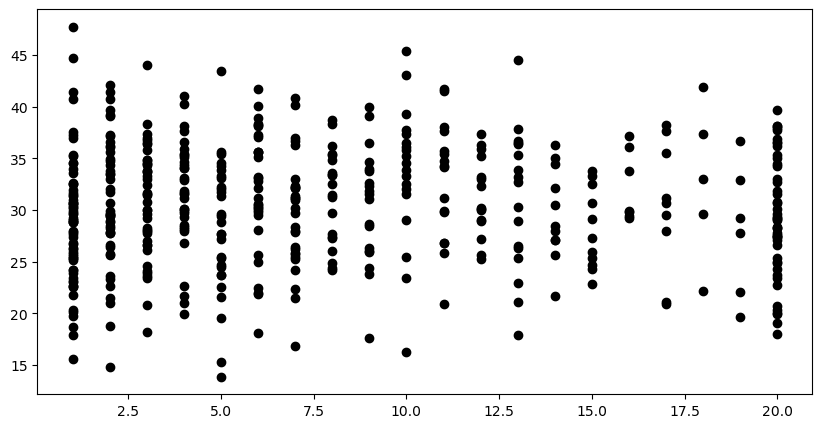

In [120]:
plt.figure(figsize=(10, 5))
plt.scatter(x=cdf["Previous Purchases"], y= cdf["Purchase Amount (USD)"], color = "black", 
            label = cdf["Promo Code Used"] == "yes" )
plt.xlabel = "No. Of Purchases", 
plt.ylabel = "Purchase Amount in USD" 
plt.title = "Relationship between Previous Purchases and Purchase Amounts in USD"
#plt.scatter([1] * len(standard_lane), standard_lane, color="tomato",    alpha=0.6, s=60)
plt.show()